In [27]:
# pytorch
import torch
from torch import nn
from torch.utils.data import DataLoader

import random
from timeit import default_timer as timer
from tqdm.auto import tqdm

# torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import v2

# matplotlib visualization
import matplotlib.pyplot as plt

# matrix
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# versions
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Using device: cuda
torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [2]:
try:
  import torchmetrics, mlxtend
  print(f"torchmetrics version: {torchmetrics.__version__}")
  print(f"mlxtend version: {mlxtend.__version__}")
except:
  !pip install torchmetrics mlxtend
  import torchmetrics, mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.2 MB/s eta 0:00:00


In [33]:
BATCH_SIZE = 32
HIDDEN_UNITS = 10
NUM_CLASSES = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load FashionMNIST datasets
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# Prepare DataLoaders
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
    pin_memory=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    persistent_workers=True,
    pin_memory=True
)

print(f"Train batches: {len(train_dataloader)} | Test batches: {len(test_dataloader)}")

Train batches: 1875 | Test batches: 313


In [34]:
len(train_data), len(test_data)

(60000, 10000)

In [35]:
class FashionMNISTModelV1BN(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()

        self.convol_block = nn.Sequential(
            nn.Conv2d(input_shape,
                      hidden_units,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units,
                      hidden_units,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )

        self.convol_block2 = nn.Sequential(
            nn.Conv2d(hidden_units,
                      hidden_units,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units,
                      hidden_units,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 7 * 7,
                      output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.convol_block2(self.convol_block(x)))

In [36]:
model = FashionMNISTModelV1BN(1, HIDDEN_UNITS, NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)

In [37]:
def accuracy_fn(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    if y_pred.ndim == 2:
        y_pred = torch.argmax(y_pred, dim=1)
    return (torch.eq(y_true, y_pred).sum().item() / len(y_true)) * 100

In [38]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               accuracy_fn,
               device):

  model.train()
  train_loss, train_acc = 0.0, 0.0
  for X, y in tqdm(dataloader):
    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    y_logits = model(X)
    loss = loss_fn(y_logits, y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y, y_pred=y_logits)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model,
              dataloader,
              loss_fn,
              accuracy_fn,
              device):

  model.eval()
  test_loss, test_acc = 0.0, 0.0

  with torch.inference_mode():
    for X, y in tqdm(dataloader):
      X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
      test_logits = model(X)
      test_loss += loss_fn(test_logits, y).item()
      test_acc += accuracy_fn(y_true=y, y_pred=test_logits)

  return test_loss / len(dataloader), test_acc / len(dataloader)


In [39]:
NUM_EPOCHS = 5

results = {"train_loss": [],
           "train_acc": [],
           "test_loss": [],
           "test_acc": []}

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Training Epochs"):
  train_loss, train_acc = train_step(model=model,
                                    dataloader=train_dataloader,
                                    loss_fn=loss_fn,
                                    optimizer=optimizer,
                                    accuracy_fn=accuracy_fn,
                                    device=device)
  test_loss, test_acc = test_step(model=model,
                                dataloader=test_dataloader,
                                loss_fn=loss_fn,
                                accuracy_fn=accuracy_fn,
                                device=device)

  results["train_loss"].append(train_loss)
  results["train_acc"].append(train_acc)
  results["test_loss"].append(test_loss)
  results["test_acc"].append(test_acc)

  print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Training Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 1 | Train Loss: 0.4087 | Train Acc: 85.46% | Test Loss: 0.3312 | Test Acc: 88.33%


  0%|          | 0/1875 [00:00<?, ?it/s]

...

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 4 | Train Loss: 0.2446 | Train Acc: 91.15% | Test Loss: 0.2646 | Test Acc: 90.14%


  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 5 | Train Loss: 0.2326 | Train Acc: 91.70% | Test Loss: 0.2715 | Test Acc: 90.16%


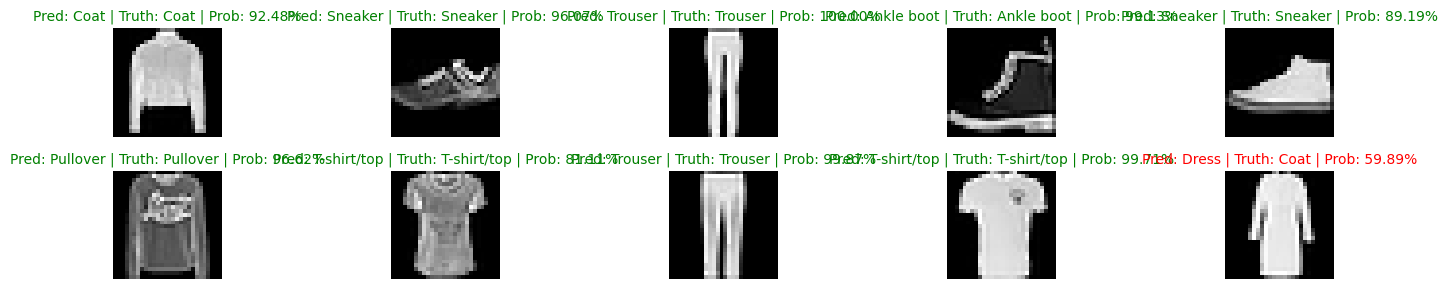

In [40]:
model.eval()

class_names = test_data.classes

# random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=10):
  test_samples.append(sample)
  test_labels.append(label)

plt.figure(figsize=(15, 3))

with torch.inference_mode():
  for i, sample in enumerate(test_samples):
    sample_tensor = sample.unsqueeze(dim=0).to(device)
    target_logit = model(sample_tensor)
    target_prob = torch.softmax(target_logit, dim=1)

    pred_label = torch.argmax(target_prob, dim=1).item()
    pred_class = class_names[pred_label]
    truth_class = class_names[test_labels[i]]
    pred_prob = target_prob[0][pred_label].item() * 100


    plt.subplot(2, 5, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")

    title_color = "green" if pred_class == truth_class else "red"
    plt.title(
        f"Pred: {pred_class} | Truth: {truth_class} | Prob: {pred_prob:.2f}%",
        color=title_color,
        fontsize=10)
    plt.axis(False)

plt.tight_layout()
plt.show()

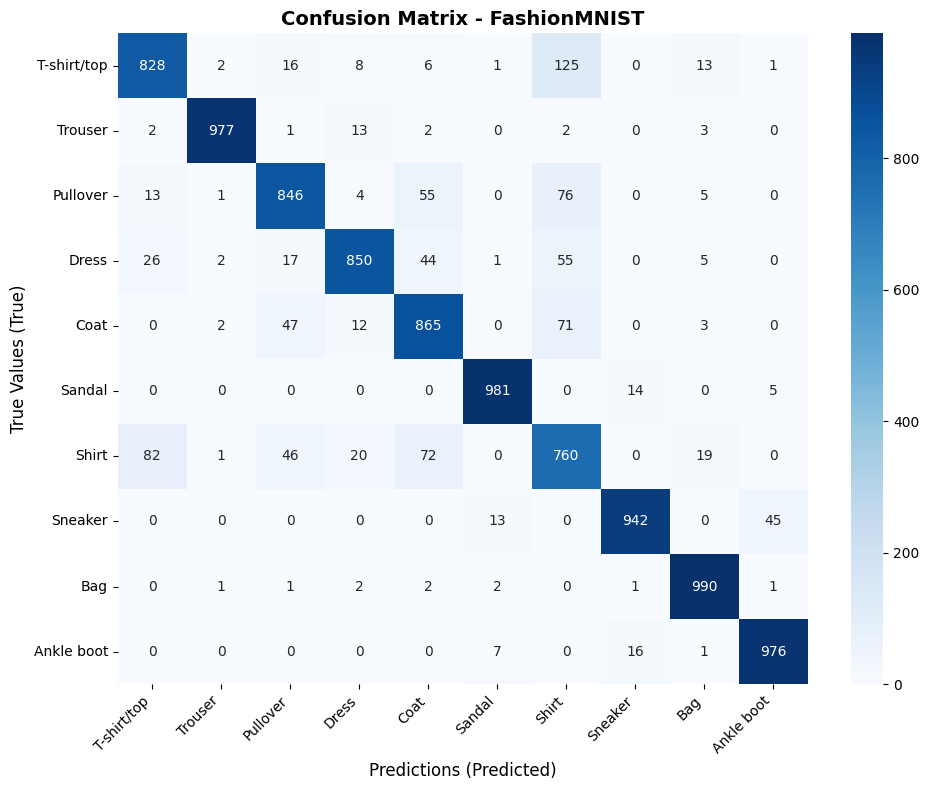

In [41]:
model.eval()

y_preds = []
y_trues = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        y_preds.append(preds.cpu())
        y_trues.append(y.cpu())

y_pred_tensor = torch.cat(y_preds).numpy()
y_true_tensor = torch.cat(y_trues).numpy()

cm = confusion_matrix(y_true_tensor, y_pred_tensor)

class_names = test_data.classes

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - FashionMNIST", fontsize=14, fontweight="bold")
plt.xlabel("Predictions (Predicted)", fontsize=12)
plt.ylabel("True Values (True)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
input_tensor = torch.rand(size=(1, 3, 64, 64))

conv_small = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=0)
out_small = conv_small(input_tensor)

conv_large = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=7, stride=1, padding=0)
out_large = conv_large(input_tensor)

print(f"Original Input: {input_tensor.shape}")
print(f"Output Small kernel=3: {out_small.shape}")
print(f"Output Large kernel=7: {out_large.shape}")

Original Input: torch.Size([1, 3, 64, 64])
Output Small kernel=3: torch.Size([1, 16, 62, 62])
Output Large kernel=7: torch.Size([1, 16, 58, 58])


Total missclassified images: 985 de 10000


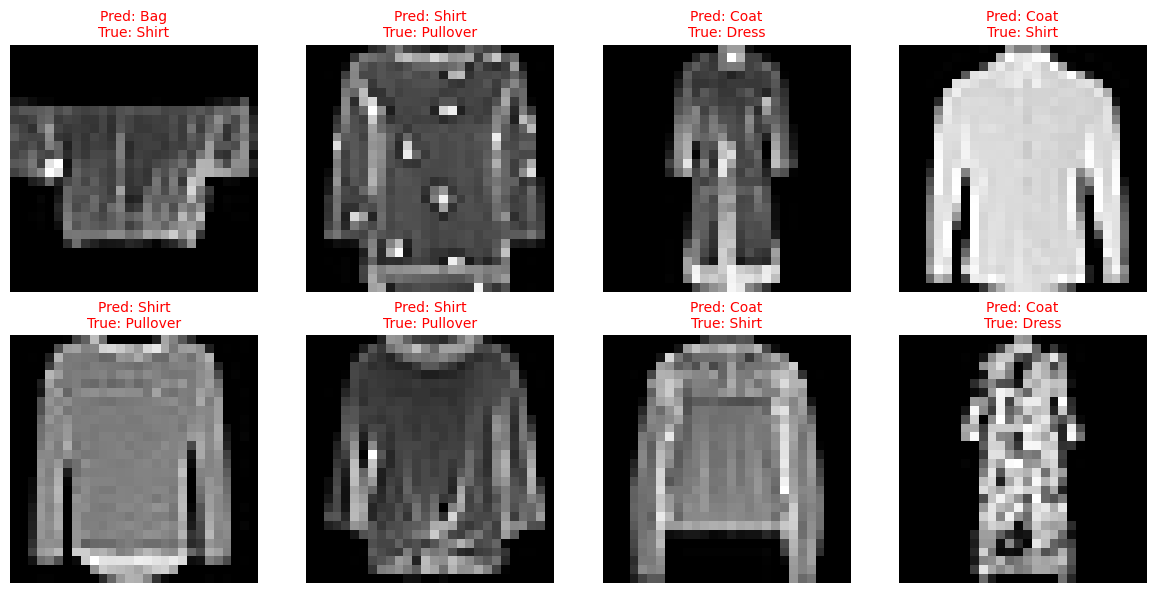

In [43]:
model.eval()

wrong_indices = []
with torch.inference_mode():
    for idx, (X_img, y_true) in enumerate(test_data):

        logits = model(X_img.unsqueeze(0).to(device))
        pred_label = torch.argmax(logits, dim=1).item()

        if pred_label != y_true:
            wrong_indices.append((idx, pred_label, y_true))

print(f"Total missclassified images: {len(wrong_indices)} de {len(test_data)}")

random.seed(42)
sample_wrongs = random.sample(wrong_indices, k=8)

plt.figure(figsize=(12, 6))
for i, (idx, pred, true) in enumerate(sample_wrongs):
    img, _ = test_data[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")

    pred_name = class_names[pred]
    true_name = class_names[true]

    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", color="red", fontsize=10)
    plt.axis(False)

plt.tight_layout()
plt.show()